# **CausalX** v0.1.0: Uplift modeling for marketing optimization

## 1. Project overview
This project implements **CausalX**, an framework designed to optimize marketing campaigns using Causal Inference. Unlike traditional predictive modeling, CausalX identifies the **incremental impact** (Uplift) of a treatment, allowing for precise customer targeting and ROI maximization.

## 2. Key features
- **Double Machine Learning (DML):** Uses LightGBM and EconML to isolate treatment effects from confounding variables.
- **Heterogeneous Treatment Effects (CATE):** Estimates individual-level uplift to differentiate between 'Persuadables', 'Sure Things', and 'Lost Causes'.
- **Robustness Testing:** Integrates automated Placebo Refutation tests to validate causal assumptions.
- **Decision Engine:** Translates statistical scores into financial decisions based on unit costs and expected returns.

## 3. Technology stack
- **Python** (Pandas, NumPy, Matplotlib, Seaborn)
- **DoWhy:** For causal identification and refutation.
- **EconML:** For advanced CATE estimation (Causal Forests).
- **Graphviz:** For Directed Acyclic Graph (DAG) visualization.

## 4. Business impact demonstration
Using the Kevin Hillstrom dataset, CausalX demonstrated an **estimated incremental profit of $46,491.86** by filtering out customers who would have purchased regardless or who were negatively impacted by the campaign.

# Dependencies

In [2]:
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dowhy
from dowhy import CausalModel
from econml.dml import CausalForestDML
from lightgbm import LGBMRegressor, LGBMClassifier
import warnings
import kagglehub
import os
import pandas as pd
import numpy as np
from dowhy import CausalModel
from econml.dml import CausalForestDML
from lightgbm import LGBMRegressor, LGBMClassifier
warnings.filterwarnings('ignore')

# Product prototype

In [3]:
class CausalX:
    def __init__(self, cost_per_unit=0.10, seed=42):
        self.cost_per_unit = cost_per_unit
        self.seed = seed
        self.causal_model = None
        self.identified_estimand = None

    def __repr__(self):
        status = 'Trained' if self.causal_model else 'Uninitialized'
        return f"CausalX(cost_per_unit={self.cost_per_unit}, seed={self.seed}, status='{status}')"

    def run_pipeline(self, df, treatment, outcome, features, dag_string):
        self.causal_model = CausalModel(data=df, treatment=treatment, outcome=outcome, graph=dag_string)
        self.identified_estimand = self.causal_model.identify_effect(proceed_when_unidentifiable=True)
        ate = self.causal_model.estimate_effect(self.identified_estimand, method_name="backdoor.propensity_score_weighting")

        X, T, Y = df[features], df[treatment], df[outcome]
        model = CausalForestDML(model_y=LGBMRegressor(n_estimators=50, verbose=-1, random_state=self.seed),
                                 model_t=LGBMClassifier(n_estimators=50, verbose=-1, random_state=self.seed),
                                 discrete_treatment=True,
                                 cv=3,
                                 random_state=self.seed)
        model.fit(Y, T, X=X)

        df['uplift_score'] = model.effect(X)
        df['suggested_action'] = (df['uplift_score'] - self.cost_per_unit) > 0

        return ate, df

    def validate_robustness(self, simulations):
        """Performs a deterministic placebo test"""
        estimate = self.causal_model.estimate_effect(self.identified_estimand, method_name="backdoor.propensity_score_weighting")
        num_simulations = simulations
        refutation = self.causal_model.refute_estimate(
            estimand=self.identified_estimand,
            estimate=estimate,
            method_name="placebo_treatment_refuter",
            placebo_type="permute",
            num_simulations=num_simulations,
            random_seed=self.seed
        )
        return refutation

# Use case

In [4]:
path = kagglehub.dataset_download("bofulee/kevin-hillstrom-minethatdata-e-mailanalytics")
df_raw = pd.read_csv(os.path.join(path, "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"))

df_raw['treatment'] = np.where(df_raw['segment'] == 'Mens E-Mail', 1, 0)
df_raw = df_raw[df_raw['segment'] != 'Womens E-Mail']

100%|██████████| 497k/497k [00:00<00:00, 576kB/s]

Extracting files...


In [5]:
engine = CausalX(cost_per_unit=0.20, seed=42)
engine

CausalX(cost_per_unit=0.2, seed=42, status='Uninitialized')

In [6]:
params = {
    'treatment': 'treatment',
    'outcome': 'spend',
    'features': ['recency', 'history', 'mens', 'newbie'],
    'dag_string': "digraph {recency -> treatment; history -> treatment; treatment -> spend; history -> spend; recency -> spend;}"
}

In [7]:
ate_est, final_df = engine.run_pipeline(df_raw, **params)

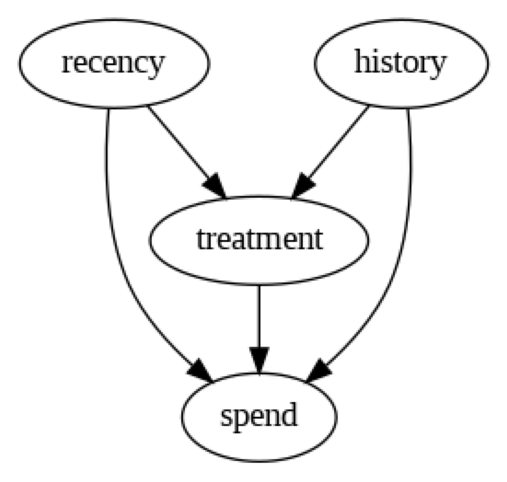

In [8]:
engine.causal_model.view_model()

In [9]:
print(f"ATE: ${ate_est.value:.2f}")
print(f"Recommendation: {final_df['suggested_action'].sum()}")
print(final_df[['uplift_score', 'suggested_action']].head())

ATE: $0.77
Recommendation: 20342
    uplift_score  suggested_action
1      -0.354410             False
3       4.554746              True
8       4.808749              True
13      0.512150              True
14     -0.064994             False


In [10]:
refutation = engine.validate_robustness(simulations=1_000)
print(refutation)

Refute: Use a Placebo Treatment
Estimated effect:0.7690513389410489
New effect:-0.008610363827375019
p value:0.948



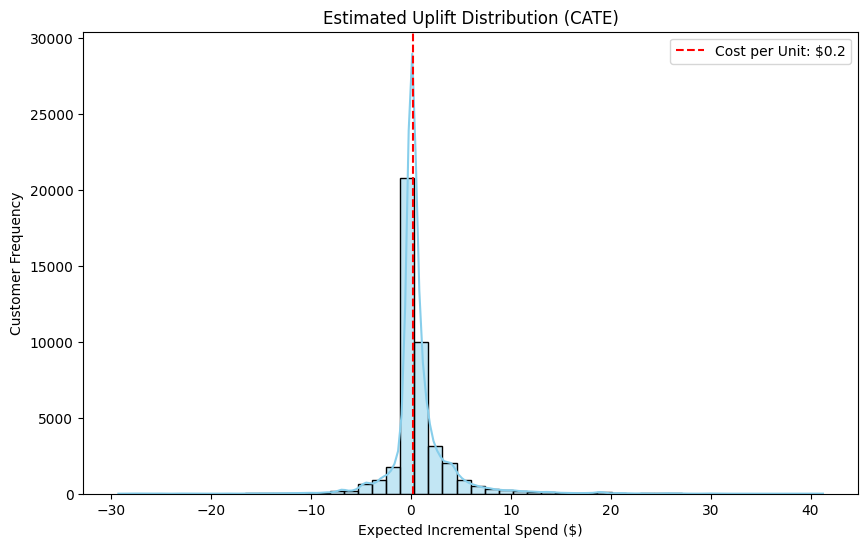


Estimated Incremental Profit with CausalX strategy: $46491.86


In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(final_df['uplift_score'], bins=50, kde=True, color='skyblue')
plt.axvline(engine.cost_per_unit, color='red', linestyle='--', label=f'Cost per Unit: ${engine.cost_per_unit}')
plt.title('Estimated Uplift Distribution (CATE)')
plt.xlabel('Expected Incremental Spend ($)')
plt.ylabel('Customer Frequency')
plt.legend()
plt.show()

# Simulated ROI Calculation
roi_total = final_df.loc[final_df['suggested_action'], 'uplift_score'].sum() - (final_df['suggested_action'].sum() * engine.cost_per_unit)
print()
print(f"Estimated Incremental Profit with CausalX strategy: ${roi_total:.2f}")